# **Explore entities by category 🔎**

This notebook allows exploration annotated entities.

## **Load libraries and setup**


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud

In [2]:
%load_ext watermark
%watermark

Last updated: 2026-07-08T17:07:03.555346+02:00

Python implementation: CPython
Python version       : 3.13.7
IPython version      : 8.13.2

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 6.17.0-35-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 32
Architecture: 64bit



## **Load data**


In [3]:
entities_path = Path("../data/entities.tsv")

In [4]:
entities_df = pd.read_csv(entities_path, sep="\t")
entities_df

,entity,category,json_file
0,villin headpiece,MOL,figshare_3983526.json
1,6µs,STIME,figshare_3983526.json
2,acemd,SOFTNAME,figshare_3983526.json
3,charmm 27,FFM,figshare_3983526.json
4,2rjy,MOL,figshare_3983526.json
...,...,...,...
2514,dppc,MOL,zenodo_4445375.json
2515,cholesterol,MOL,zenodo_4445375.json
2516,gromacs,SOFTNAME,zenodo_4445375.json
2517,martini 2,FFM,zenodo_4445375.json


In [5]:
# Aggregate by 'entity' and 'category' to separate entities like 'charmm'
# that could be both FFM and SOFTNAME.
entities_by_category = (entities_df
 .groupby(["entity", "category"])
 .agg(
     occurrence=("entity", "count"),
     json_files=("json_file", ",".join),
     number_of_files=("json_file", "nunique")
 )
  .reset_index()
)
entities_by_category

,entity,category,occurrence,json_files,number_of_files
0,(gvpgv)7,MOL,1,figshare_5532214.json,1
1,0.11,SOFTVERS,1,zenodo_15483080.json,1
2,0.5 μs,STIME,1,zenodo_4106413.json,1
3,0.6.0,SOFTVERS,1,zenodo_15483080.json,1
4,08.12.2025,SOFTVERS,1,zenodo_17867182.json,1
...,...,...,...,...,...
931,α3β2 nachr,MOL,2,"zenodo_3908769.json,zenodo_3908769.json",1
932,α‑amylase,MOL,1,figshare_20376757.json,1
933,β-sesquiphellandrene,MOL,3,"zenodo_18468770.json,zenodo_18468770.json,zeno...",1
934,βol15,FFM,1,figshare_19102457.json,1


In [6]:
# Aggregate by category
entities_agg = (entities_by_category
 .groupby("category")
 .agg(
     total_entities=("occurrence", "sum"),
     unique_entities=("entity", "nunique")
 )
 .sort_values(by="total_entities", ascending=False)
)
entities_agg.loc["total"] = entities_agg.sum(numeric_only=True)
entities_agg

,total_entities,unique_entities
category,,
MOL,1489,558
FFM,353,113
SOFTNAME,281,64
STIME,156,75
STEMP,137,60
SOFTVERS,103,66
total,2519,936


In [7]:
def list_entities(df: pd.DataFrame, category: str) -> pd.DataFrame:
    """List entities for a given category, sorted by occurrence.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns: 'entity', 'occurrence', 'json_files', 'number_of_files'.
    """
    return (df
     .query("category == @category")
     .sort_values("occurrence", ascending=False)
     .reset_index(drop=True)
    )


def make_wordcloud(df: pd.DataFrame, category: str) -> None:
    """Make a word cloud for a given category."""
    df_tmp = list_entities(df, category)
    freq = dict(zip(df_tmp["entity"], df_tmp["number_of_files"], strict=False))
    wc = WordCloud(background_color="white", max_words=150)
    wc.generate_from_frequencies(freq)
    # show
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()

## Molecules 🧬


In [8]:
list_entities(entities_by_category, "MOL")

,entity,category,occurrence,json_files,number_of_files
0,popc,MOL,81,"zenodo_13814.json,zenodo_13814.json,zenodo_138...",33
1,dppc,MOL,45,"zenodo_1009027.json,zenodo_1009027.json,zenodo...",15
2,nacl,MOL,42,"figshare_3983526.json,zenodo_17870475.json,zen...",21
3,cholesterol,MOL,29,"figshare_14994624.json,zenodo_3988469.json,zen...",12
4,tlr4,MOL,18,"figshare_11704443.json,figshare_11704443.json,...",2
...,...,...,...,...,...
553,2kf7,MOL,1,zenodo_6791876.json,1
554,2axm,MOL,1,zenodo_18089451.json,1
555,23l,MOL,1,zenodo_573274.json,1
556,20:5(n-3),MOL,1,figshare_31390736.json,1


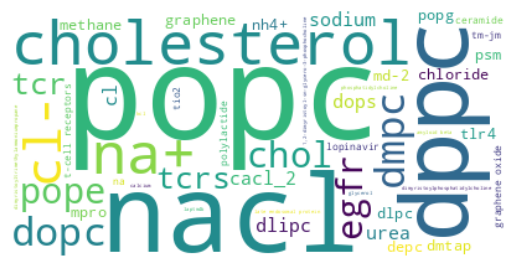

In [9]:
make_wordcloud(entities_by_category, "MOL")

## Force Field Model Name 🛠️


In [10]:
list_entities(entities_by_category, "FFM")

,entity,category,occurrence,json_files,number_of_files
0,charmm36,FFM,57,"zenodo_6988344.json,zenodo_1009027.json,zenodo...",31
1,tip3p,FFM,28,"figshare_3983526.json,zenodo_17870475.json,zen...",27
2,charmm,FFM,15,"zenodo_17870475.json,zenodo_1198158.json,zenod...",8
3,slipids,FFM,13,"zenodo_17730864.json,zenodo_3613573.json,zenod...",7
4,charmm36m,FFM,11,"zenodo_18405455.json,zenodo_17870475.json,zeno...",9
...,...,...,...,...,...
108,tip3,FFM,1,zenodo_17477539.json,1
109,tip4p/2005,FFM,1,figshare_13836577.json,1
110,tip5p,FFM,1,zenodo_18271036.json,1
111,trappe-ua,FFM,1,figshare_13836577.json,1


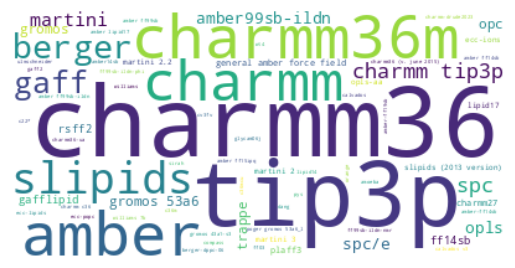

In [11]:
make_wordcloud(entities_by_category, "FFM")

## Software name ⚙️


In [12]:
list_entities(entities_by_category, "SOFTNAME")

,entity,category,occurrence,json_files,number_of_files
0,gromacs,SOFTNAME,117,"zenodo_13814.json,zenodo_13814.json,zenodo_177...",79
1,charmm-gui,SOFTNAME,20,"zenodo_1129456.json,zenodo_3988469.json,zenodo...",17
2,namd,SOFTNAME,15,"zenodo_17870475.json,zenodo_17870475.json,zeno...",9
3,vmd,SOFTNAME,11,"zenodo_17870475.json,zenodo_6879091.json,zenod...",7
4,auto-martinim3,SOFTNAME,7,"zenodo_17790588.json,zenodo_17790588.json,zeno...",1
...,...,...,...,...,...
59,statannotations,SOFTNAME,1,zenodo_15483080.json,1
60,suave,SOFTNAME,1,zenodo_18207146.json,1
61,stride,SOFTNAME,1,zenodo_17477539.json,1
62,unitymol,SOFTNAME,1,zenodo_5060102.json,1


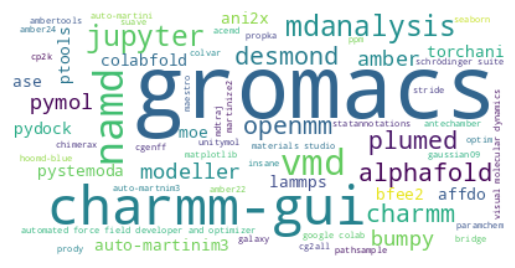

In [13]:
make_wordcloud(entities_by_category, "SOFTNAME")

## Software version 🔢


In [14]:
list_entities(entities_by_category, "SOFTVERS")

,entity,category,occurrence,json_files,number_of_files
0,4.5,SOFTVERS,9,"zenodo_13814.json,zenodo_13814.json,zenodo_138...",5
1,2,SOFTVERS,9,"zenodo_15863910.json,zenodo_15863910.json,zeno...",1
2,5.1.4,SOFTVERS,5,"zenodo_17730864.json,zenodo_17730864.json,zeno...",4
3,2023.3,SOFTVERS,4,"zenodo_18437736.json,zenodo_17867182.json,zeno...",4
4,4.0.7,SOFTVERS,3,"zenodo_14591.json,zenodo_14591.json,zenodo_129...",2
...,...,...,...,...,...
61,v. 5.0,SOFTVERS,1,zenodo_51185.json,1
62,v4.5.3,SOFTVERS,1,figshare_4508975.json,1
63,v9.16,SOFTVERS,1,figshare_13135976.json,1
64,version 2.6.0,SOFTVERS,1,zenodo_3865919.json,1


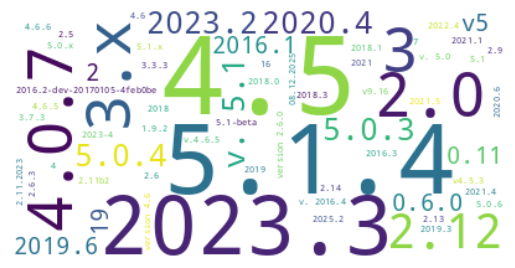

In [15]:
make_wordcloud(entities_by_category, "SOFTVERS")

## Simulation time ⏱


In [16]:
list_entities(entities_by_category, "STIME")

,entity,category,occurrence,json_files,number_of_files
0,100 ns,STIME,17,"zenodo_17730864.json,zenodo_17730864.json,zeno...",13
1,500 ns,STIME,12,"zenodo_5226209.json,zenodo_10261345.json,zenod...",10
2,500ns,STIME,12,"zenodo_1009027.json,zenodo_1009027.json,zenodo...",2
3,200 ns,STIME,10,"zenodo_1167532.json,figshare_4806544.json,zeno...",8
4,1 microsecond,STIME,5,"figshare_20485017.json,zenodo_1488094.json,zen...",5
...,...,...,...,...,...
70,8 microseconds,STIME,1,zenodo_5226209.json,1
71,800 ns,STIME,1,zenodo_259443.json,1
72,87 microsecond,STIME,1,zenodo_7323535.json,1
73,hundred nanosecond,STIME,1,figshare_13135976.json,1


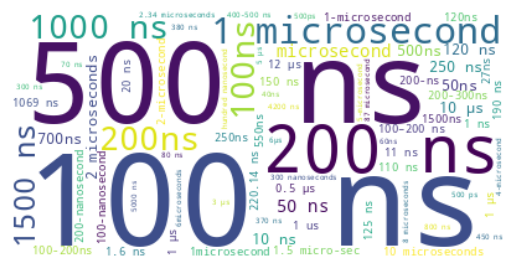

In [17]:
make_wordcloud(entities_by_category, "STIME")

## Temperature 🌡️


In [18]:
list_entities(entities_by_category, "TEMP")

,entity,category,occurrence,json_files,number_of_files


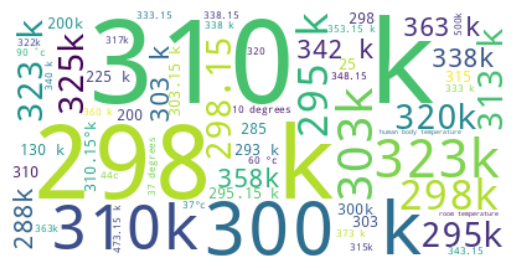

In [19]:
make_wordcloud(entities_by_category, "STEMP")